## ICE Plot — What it shows (intuition)

ICE plots show how a prediction changes for each individual sample as one feature varies, while others are fixed.
PDP = average behavior
ICE = individual behavior

### Imports & Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay

sns.set(style="whitegrid")
np.random.seed(42)


In [2]:
# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


### Train Model

In [3]:
model = RandomForestClassifier(
    n_estimators=300,
    max_depth=6,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

### Basic ICE Plot (Single Feature)

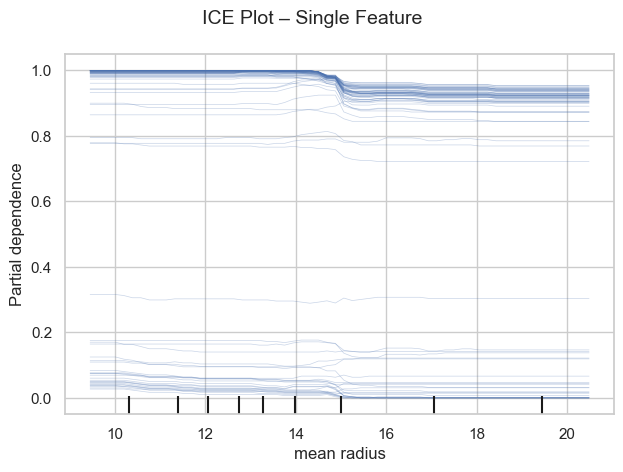

In [4]:
PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=["mean radius"],
    kind="individual",      # ICE only
    subsample=80,
    grid_resolution=60
)

plt.suptitle("ICE Plot – Single Feature", fontsize=14)
plt.tight_layout()
plt.show()


### ICE + PDP Together (Most Recommended)

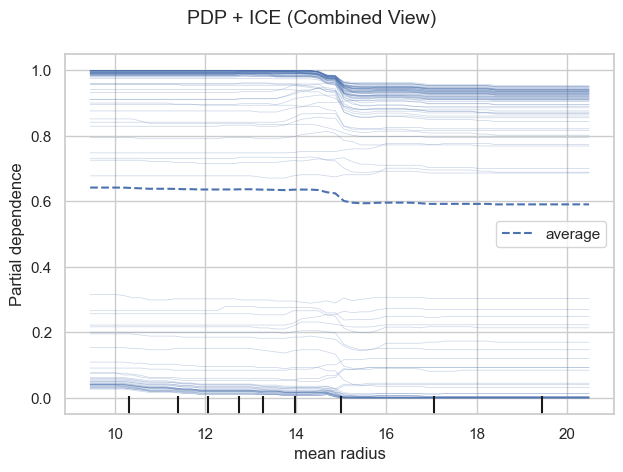

In [5]:
PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=["mean radius"],
    kind="both",            # PDP + ICE
    subsample=100,
    grid_resolution=60
)

plt.suptitle("PDP + ICE (Combined View)", fontsize=14)
plt.tight_layout()
plt.show()


### Centered ICE (c-ICE)
✔ Removes baseline → focuses on change

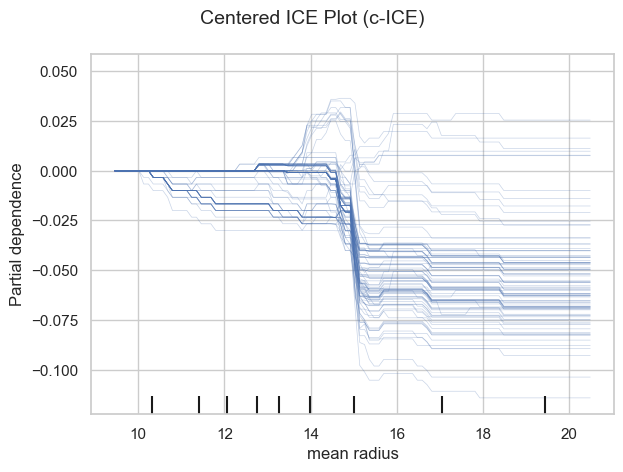

In [6]:
PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=["mean radius"],
    kind="individual",
    centered=True,
    subsample=100
)

plt.suptitle("Centered ICE Plot (c-ICE)", fontsize=14)
plt.tight_layout()
plt.show()


### ICE for Multiple Features

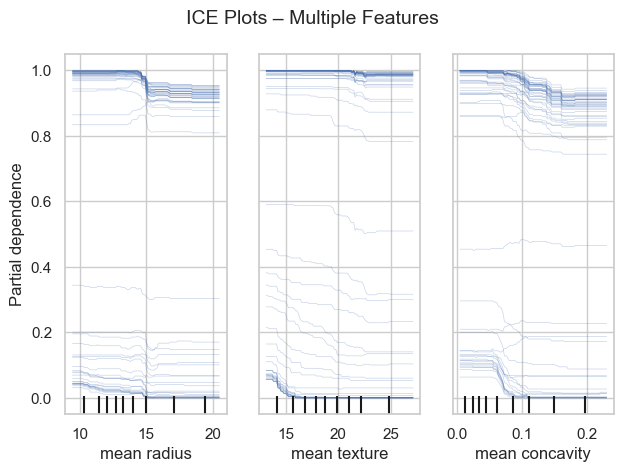

In [7]:
features = ["mean radius", "mean texture", "mean concavity"]

PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=features,
    kind="individual",
    subsample=60,
    n_cols=3
)

plt.suptitle("ICE Plots – Multiple Features", fontsize=14)
plt.tight_layout()
plt.show()


### ICE with Fewer Lines (Clarity Control)

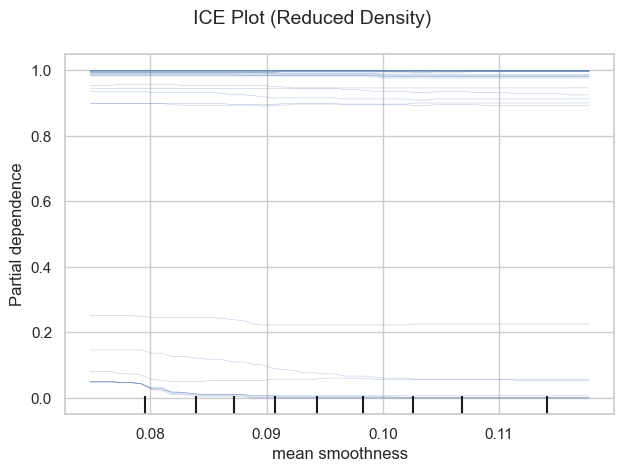

In [8]:
PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=["mean smoothness"],
    kind="individual",
    subsample=30,      # fewer lines
    grid_resolution=50
)

plt.suptitle("ICE Plot (Reduced Density)", fontsize=14)
plt.tight_layout()
plt.show()


### ICE for Classification Probabilities

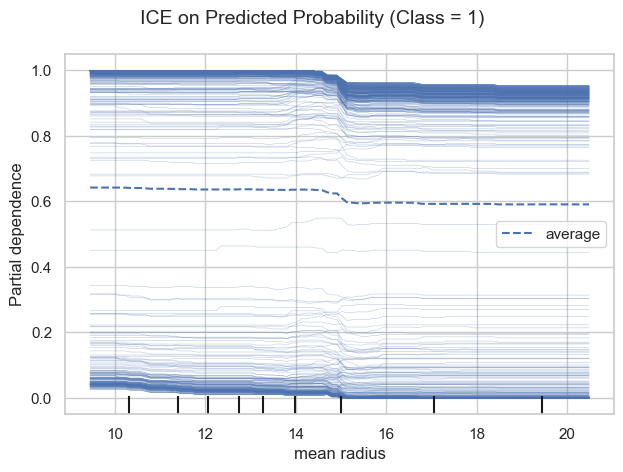

In [9]:
PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=["mean radius"],
    kind="both",
    response_method="predict_proba",
    target=1
)

plt.suptitle("ICE on Predicted Probability (Class = 1)", fontsize=14)
plt.tight_layout()
plt.show()


### ICE for Top-K Important Features

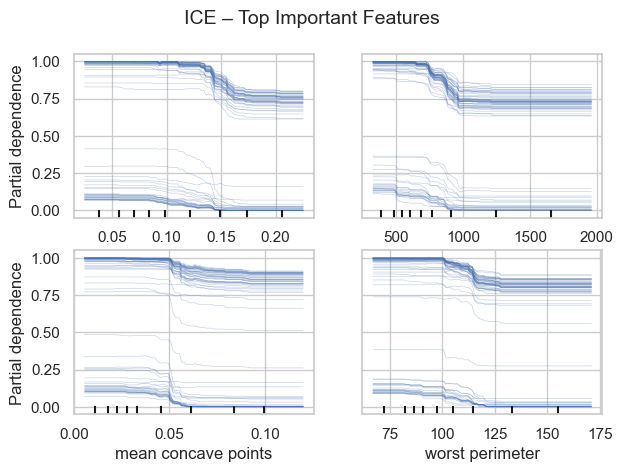

In [10]:
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_features = importances.head(4).index.tolist()

PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=top_features,
    kind="individual",
    subsample=70,
    n_cols=2
)

plt.suptitle("ICE – Top Important Features", fontsize=14)
plt.tight_layout()
plt.show()


### Custom Styled ICE Plot

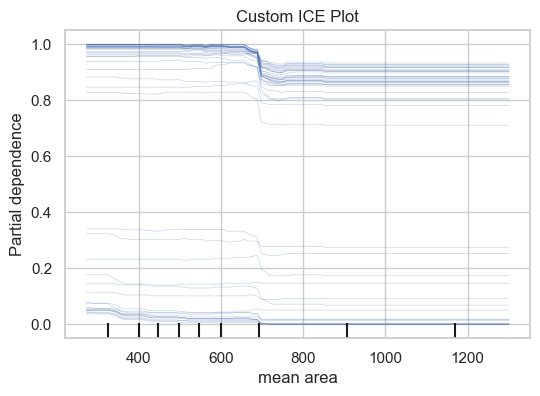

In [11]:
fig, ax = plt.subplots(figsize=(6, 4))

PartialDependenceDisplay.from_estimator(
    model,
    X_train,
    features=["mean area"],
    kind="individual",
    subsample=50,
    ax=ax
)

ax.set_title("Custom ICE Plot")
ax.set_ylabel("Prediction")
plt.show()
